
<div dir=ltr align=center>

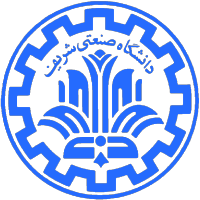

<font color=0F5298 size=7>
Machine Learning <br>
<font color=2565AE size=5>
Computer Engineering Department <br>
Fall 2025 <br>
<font color=3C99D size=5>
    Clustering: K-Means Clustering<br>
<font color=696880 size=4>
    Prepared by Benyamin Ghanbari <br>

<font color=696880 size=2>
    Curated by Alireza Mirshafieian

____

# Student Information

In [ ]:
full_name = 'Mahdi Ghorbani'

### Image Segmentation Using K-Means Clustering for Color-Based Region Extraction

### Description:

In this project, you will implement **K-Means clustering from scratch** and use it to perform image segmentation based on color similarity. **Image segmentation** is the process of dividing an image into meaningful regions. In this assignment, segmentation is done using **color clustering**, where every pixel is grouped into one of K color clusters.

**⚠️ Notice:** You are allowed to use **only the imported libraries** and must **follow the provided function structure**.



# 📝 **Project Instructions**

1. **Load the image**  
   Load the input image and convert it into an **RGB numerical array**.

2. **Reshape image to pixels**  
   Flatten the image into a **2D array**, where each row represents one pixel (**R, G, B**).

3. **Initialize K cluster centers**  
   Randomly select **K pixels** to serve as the starting cluster centers.

4. **Assign pixels to nearest cluster**  
   Compute **distances** and assign each pixel to the **closest cluster center**.

5. **Update cluster centers**  
   Recalculate each center as the **mean color** of all pixels assigned to that cluster.

6. **K-Means algorithm**  
   Repeat **assignment** and **update steps** until **convergence** or **max iterations**.

7. **Reconstruct segmented image**  
   Replace each pixel with the **color of its assigned cluster center**.

8. **Using the Elbow Method**  
   Compute the Compute Within-Cluster Sum of Squares **WCSS** for various **K values** to help estimate an **optimal K**.

9. **Run the segmentation**  
   Apply your **full K-Means pipeline** to segment the chosen image.

10. **Display results**  
    Plot and **visualize** the original and segmented images **side-by-side**.


# 📤 **Expected Output**

- A **segmented image** produced by your **K-Means implementation**  
- A **plot showing the Elbow Method curve** (**WCSS vs. K**)  
- **Observe** how changing **K** affects segmentation


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [3]:

# Step 1: Load the image

def load_image(path):

    # Open the image using PIL
    img = Image.open(path)
    # Convert to RGB
    img = img.convert('RGB')
    # Convert to numpy array
    data = np.array(img)

    return data


# Step 2: Reshape image to pixels

def preprocess_image(image_data):

    # Get the original shape
    h, w, c = image_data.shape
    # Reshape to (h*w, c) - flatten spatial dimensions
    pixels = image_data.reshape(-1, 3)

    return pixels



In [4]:

# Step 3: Initialize K cluster centers

def initialize_centers(pixels, k):

    # Get the number of pixels
    n_pixels = pixels.shape[0]
    # Randomly select k indices without replacement
    indices = np.random.choice(n_pixels, size=k, replace=False)
    # Select the corresponding pixels as centers
    centers = pixels[indices].copy()

    return centers


# Step 4: Assign pixels to nearest cluster

def assign_clusters(pixels, centers):

    # Calculate Euclidean distance between each pixel and each center
    # Using broadcasting: (n_pixels, 1, 3) - (1, k, 3) = (n_pixels, k, 3)
    distances = np.sqrt(((pixels[:, np.newaxis, :] - centers[np.newaxis, :, :]) ** 2).sum(axis=2))
    # Find the index of the closest center for each pixel
    labels = np.argmin(distances, axis=1)

    return labels


# Step 5: Update cluster centers

def update_centers(pixels, labels, k):

    # Initialize array for new centers
    new_centers = np.zeros((k, 3))

    # Calculate mean for each cluster
    for i in range(k):
        # Get all pixels assigned to cluster i
        cluster_pixels = pixels[labels == i]

        # If cluster has pixels, compute mean; otherwise keep old center or reinitialize
        if len(cluster_pixels) > 0:
            new_centers[i] = cluster_pixels.mean(axis=0)
        else:
            # If a cluster has no pixels, reinitialize randomly
            new_centers[i] = pixels[np.random.randint(0, len(pixels))]

    return np.array(new_centers)



# Step 6: K-Means algorithm

def kmeans(pixels, k, max_iters=100, tol=1e-4):

    # Step 1: Initialize centers randomly
    centers = initialize_centers(pixels, k)

    # Initialize variables
    prev_centers = centers.copy()

    # Iterate until convergence or max_iters
    for iteration in range(max_iters):
        # Step 2: Assign each pixel to the nearest cluster
        labels = assign_clusters(pixels, centers)

        # Step 3: Update cluster centers
        centers = update_centers(pixels, labels, k)

        # Check for convergence: if centers haven't moved much
        center_shift = np.sqrt(((centers - prev_centers) ** 2).sum(axis=1)).max()

        if center_shift < tol:
            print(f"Converged after {iteration + 1} iterations")
            break

        # Update previous centers for next iteration
        prev_centers = centers.copy()

    return centers, labels

In [5]:

# Step 7: Reconstruct segmented image

def recreate_image(labels, centers, image_shape):

    # Replace each pixel label with its corresponding cluster center color
    segmented_pixels = centers[labels]

    # Reshape back to original image shape
    segmented = segmented_pixels.reshape(image_shape)

    # Convert to uint8 (valid image data type)
    segmented = segmented.astype(np.uint8)

    return segmented

In [6]:
# Step 8: Elbow Method

def calculate_wcss(pixels, max_k=10):
    wcss = []

    # Try different values of k from 1 to max_k
    for k in range(1, max_k + 1):
        print(f"Calculating WCSS for k={k}...")

        # Run K-Means for current k
        centers, labels = kmeans(pixels, k, max_iters=100)

        # Calculate WCSS for this k
        # WCSS = sum of squared distances of each point to its cluster center
        current_wcss = 0.0

        for i in range(k):
            # Get all pixels in cluster i
            cluster_pixels = pixels[labels == i]

            if len(cluster_pixels) > 0:
                # Calculate squared distance from each point to its center
                distances = np.sqrt(((cluster_pixels - centers[i]) ** 2).sum(axis=1))
                squared_distances = distances ** 2
                current_wcss += squared_distances.sum()

        wcss.append(current_wcss)

    return wcss

def plot_elbow(wcss):

    k_values = range(1, len(wcss) + 1)

    # Create the plot
    plt.figure(figsize=(6, 4))
    plt.plot(k_values, wcss, 'bo-', linewidth=2, markersize=8)

    # Customize the plot
    plt.xlabel('Number of Clusters (k)', fontsize=12)
    plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
    plt.title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.xticks(k_values)

    plt.show()


In [7]:
# Step 9: Run the segmentation

def run_segmentation(image_path, k):

    # 1. Load image
    image_data = load_image(image_path)
    original_shape = image_data.shape

    # 2. Preprocess to pixels
    pixels = preprocess_image(image_data)

    # 3. Run K-Means
    centers, labels = kmeans(pixels, k, max_iters=100)

    # 4. Reconstruct image
    segmented_image = recreate_image(labels, centers, original_shape)

    return image_data, segmented_image, centers, labels, pixels

In [8]:
# Step 10: Display results

def display_results(original_image, segmented_image, k, centers, labels):

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Original image
    axes[0].imshow(original_image)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    # Segmented image
    axes[1].imshow(segmented_image)
    axes[1].set_title(f'Segmented Image (k={k})')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()


Converged after 29 iterations


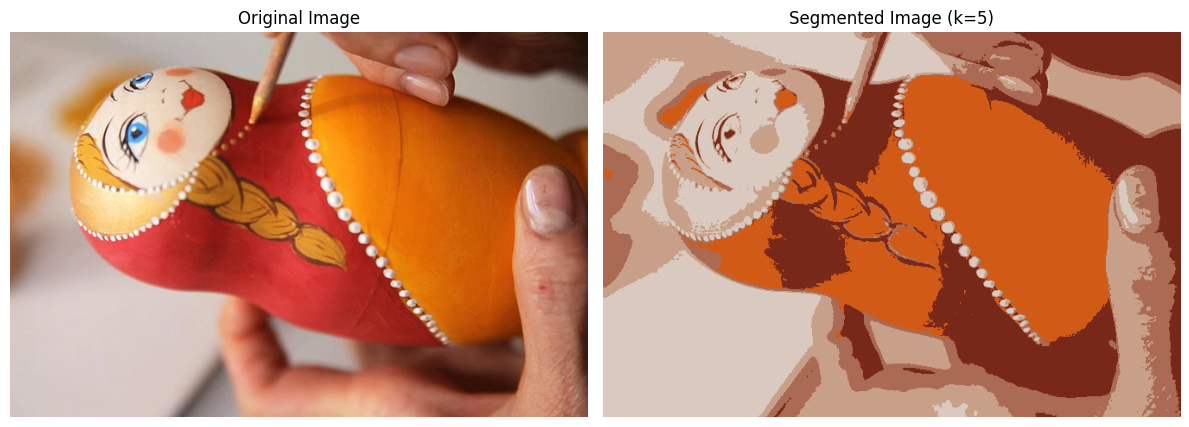

Calculating WCSS for k=1...
Converged after 2 iterations
Calculating WCSS for k=2...
Converged after 9 iterations
Calculating WCSS for k=3...
Converged after 24 iterations
Calculating WCSS for k=4...
Converged after 34 iterations
Calculating WCSS for k=5...
Converged after 30 iterations
Calculating WCSS for k=6...
Converged after 40 iterations
Calculating WCSS for k=7...
Converged after 70 iterations
Calculating WCSS for k=8...
Converged after 72 iterations
Calculating WCSS for k=9...
Converged after 49 iterations
Calculating WCSS for k=10...
Converged after 37 iterations


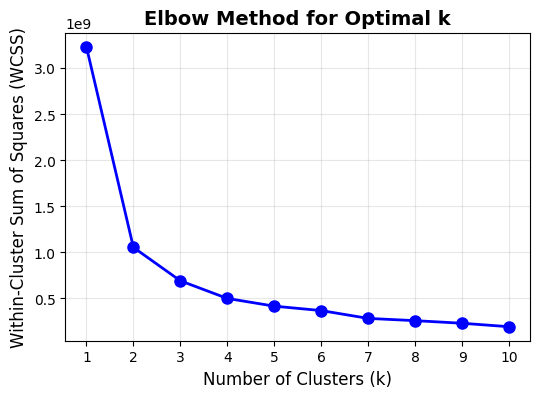

In [9]:

image_path = "/content/matryoshka.jpg"
k = 5

# Step 9: Run the segmentation
original, segmented, centers, labels, pixels = run_segmentation(image_path, k)

# Step 10: Display results
display_results(original, segmented, k, centers, labels)

# Elbow Method
wcss = calculate_wcss(pixels, max_k=10)
plot_elbow(wcss)

Converged after 23 iterations


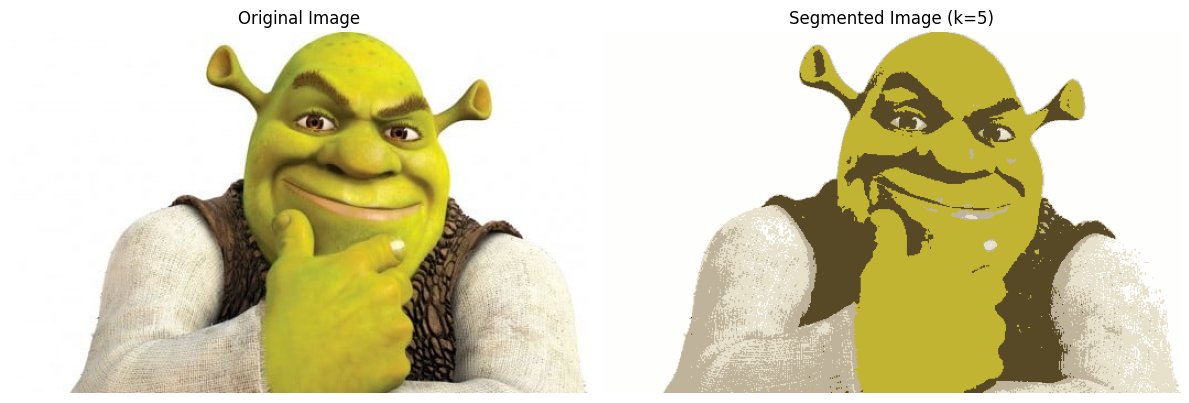

Calculating WCSS for k=1...
Converged after 2 iterations
Calculating WCSS for k=2...
Converged after 9 iterations
Calculating WCSS for k=3...
Converged after 17 iterations
Calculating WCSS for k=4...
Converged after 16 iterations
Calculating WCSS for k=5...
Converged after 27 iterations
Calculating WCSS for k=6...
Converged after 25 iterations
Calculating WCSS for k=7...
Converged after 61 iterations
Calculating WCSS for k=8...
Converged after 75 iterations
Calculating WCSS for k=9...
Calculating WCSS for k=10...
Converged after 82 iterations


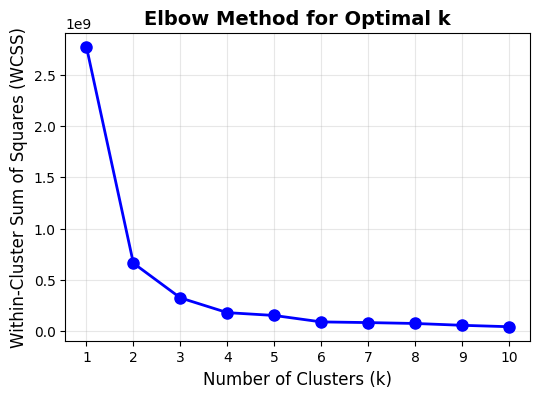

In [10]:
image_path = "/content/shrek.jpg"
k = 5

# Step 9: Run the segmentation
original, segmented, centers, labels, pixels = run_segmentation(image_path, k)

# Step 10: Display results
display_results(original, segmented, k, centers, labels)

# Elbow Method
wcss = calculate_wcss(pixels, max_k=10)
plot_elbow(wcss)

Converged after 68 iterations


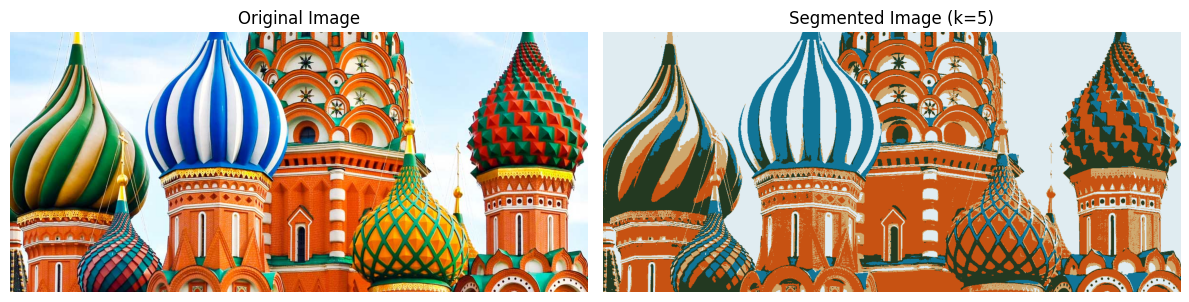

Calculating WCSS for k=1...
Converged after 2 iterations
Calculating WCSS for k=2...
Converged after 15 iterations
Calculating WCSS for k=3...
Converged after 15 iterations
Calculating WCSS for k=4...
Converged after 42 iterations
Calculating WCSS for k=5...
Converged after 38 iterations
Calculating WCSS for k=6...
Converged after 41 iterations
Calculating WCSS for k=7...
Calculating WCSS for k=8...
Converged after 58 iterations
Calculating WCSS for k=9...
Converged after 80 iterations
Calculating WCSS for k=10...


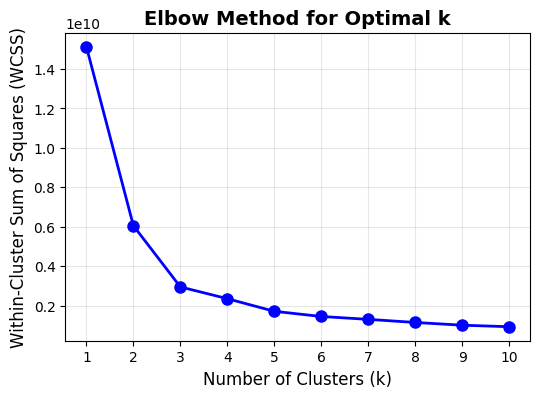

In [12]:
image_path = "/content/st.basils.jpg"
k = 5

# Step 9: Run the segmentation
original, segmented, centers, labels, pixels = run_segmentation(image_path, k)

# Step 10: Display results
display_results(original, segmented, k, centers, labels)

# Elbow Method
wcss = calculate_wcss(pixels, max_k=10)
plot_elbow(wcss)